# AIFS and Modern AI Forecasting

The previous notebooks built the operator-learning story step by step:

```text
DeepONet:     function-to-function maps
FNO:          spectral operators on a periodic grid
SFNO:         spectral operators adapted to the sphere
GNN weather:  learned forecast operators on graphs and meshes
```

This notebook is the endpoint of that sequence. It explains how ECMWF's Artificial Intelligence Forecasting System (AIFS) fits into the same picture.

At the highest level, AIFS is still a learned forecast operator:

$$
\mathcal{G}_\theta: X_t \mapsto X_{t+6\mathrm{h}},
$$

applied autoregressively:

$$
X_t \rightarrow X_{t+6\mathrm{h}} \rightarrow X_{t+12\mathrm{h}} \rightarrow \cdots.
$$

The differences are scale, engineering, training data, uncertainty treatment, and operational validation.

References:

- ECMWF newsletter: [AIFS: a new ECMWF forecasting system](https://www.ecmwf.int/en/newsletter/178/news/aifs-new-ecmwf-forecasting-system)
- ECMWF update: [First update to the Artificial Intelligence Forecasting System](https://www.ecmwf.int/node/28946)
- ECMWF ensemble article: [Data-driven ensemble forecasting with AIFS](https://www.ecmwf.int/en/newsletter/181/earth-system-science/data-driven-ensemble-forecasting-aifs)
- AIFS model card: [ecmwf/aifs-single-1.1](https://huggingface.co/ecmwf/aifs-single)
- AIFS paper page: [Lang et al., 2024](https://huggingface.co/papers/2406.01465)
- Earth2Studio deterministic inference example: [NVIDIA Earth2Studio](https://nvidia.github.io/earth2studio/examples/01_deterministic_workflow.html)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(7)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = False
plt.rcParams['image.cmap'] = 'turbo'

## 1. AIFS as a forecast operator

A global forecast model does not predict one scalar label. It predicts a structured atmospheric state.

A state vector $X_t$ can include:

- upper-air variables such as geopotential, wind components, temperature, and humidity on pressure levels,
- surface variables such as surface pressure, mean sea-level pressure, 2 m temperature, 10 m winds, soil fields, and radiation/cloud/precipitation-related fields,
- static or known inputs such as orography, land-sea mask, latitude/longitude, time of day, day of year, and insolation-like forcing.

The AIFS v1.1 model card describes a six-hour forecast setup using two recent atmospheric states as input and predicting the state six hours ahead. It also notes that input/output states are normalized by variable and level, with separate handling for some forcing variables.

So the operational object is not simply

```text
image -> image
```

but closer to

```text
multi-variable, multi-level global state + known forcings -> next global state
```

This is the same operator-learning idea as before, but at operational scale.

## 2. Conceptual architecture

AIFS can be understood as an encoder-processor-decoder model.

- **Encoder:** maps the input weather state into a latent representation. Current ECMWF model-card descriptions emphasize a graph neural network encoder.
- **Processor:** evolves the latent representation. Current AIFS descriptions identify a sliding-window transformer processor.
- **Decoder:** maps the latent state back to weather variables on the output grid. Current descriptions again emphasize a graph neural network decoder.

Earlier graph weather systems and early AIFS-style models were closer to message-passing GNN processors. The current architecture uses graph components where they are useful for the interface to the weather grid and transformer components where they are useful for scalable latent processing.

The diagram hides a lot of engineering. A real operational model must track variable ordering, pressure levels, static fields, grid conventions, normalization constants, rollout state, and postprocessing. Those details matter as much as the neural network class names.

## 3. Training: one-step skill is not enough

A learned forecast operator is usually trained first to predict short lead-time targets well. But a medium-range forecast repeatedly feeds predictions back into the model. That creates a distribution shift:

```text
training input:   analyzed/reanalysis state
rollout input:    previous model prediction
```

Small one-step errors can accumulate. This is why modern forecast models use staged training, rollout fine-tuning, variable-specific loss scaling, and extensive lead-time validation.

The AIFS v1.1 model card describes pretraining on ERA5 and fine-tuning on operational-analysis rollout data. It also describes area-weighted MSE with loss scaling across variables and levels. Those choices reflect the operational problem: a single global scalar loss must balance many variables, heights, regions, and forecast lead times.

## 4. Deterministic and probabilistic forecasting

A deterministic model returns one forecast trajectory. If it is trained mainly with mean-squared error, it is rewarded for predicting conditional means. That can produce strong average RMSE while damping uncertain small-scale structures.

A probabilistic or ensemble model tries to represent a distribution of plausible future states. ECMWF's ensemble AIFS work discusses probabilistic training and stochastic mechanisms that help produce ensemble spread.

Conceptually:

- **MSE:** rewards a single forecast close to the average verifying outcome.
- **CRPS/probabilistic objectives:** reward predictive distributions that place probability mass near the verifying outcome.
- **Stochastic latent perturbations:** can help ensemble members separate, but only useful if the spread is calibrated.

This distinction matters because many forecast decisions depend on risk and uncertainty, not only the ensemble mean.

## 5. Toy demo: smoothing and autoregressive error growth

The next cell builds a one-dimensional synthetic forecast problem. The truth moves and keeps small-scale energy. The deterministic forecast is deliberately too smooth. A simple stochastic ensemble adds spread.

This is not an AIFS simulation. It is a visual analogy for two common rollout issues:

1. repeated one-step errors accumulate with lead time;
2. deterministic mean predictions can lose amplitude and fine structure.

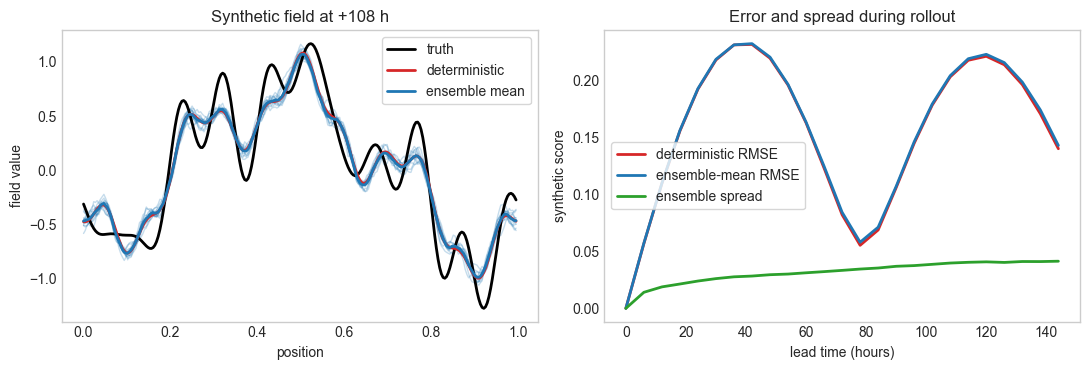

In [3]:
nx = 256
nsteps = 24
x = np.linspace(0, 1, nx, endpoint=False)


def smooth_periodic(field, strength=0.18):
    return (1 - strength) * field + 0.5 * strength * (np.roll(field, 1) + np.roll(field, -1))


def truth_step(field, k):
    advected = np.roll(field, 3)
    injection = 0.08 * np.sin(2 * np.pi * (9 * x - 0.03 * k))
    return 0.985 * advected + injection


def deterministic_step(field):
    return smooth_periodic(np.roll(field, 3), strength=0.32) * 0.98


def stochastic_step(field, k):
    noise = rng.normal(0, 0.025, size=nx)
    noise = smooth_periodic(noise, strength=0.75)
    return deterministic_step(field) + noise


initial = (
    np.sin(2 * np.pi * x)
    + 0.45 * np.sin(2 * np.pi * 4 * x + 0.4)
    + 0.2 * np.sin(2 * np.pi * 11 * x)
)

truth = [initial]
det = [initial]
members = [[initial.copy()] for _ in range(12)]

for k in range(nsteps):
    truth.append(truth_step(truth[-1], k))
    det.append(deterministic_step(det[-1]))
    for member in members:
        member.append(stochastic_step(member[-1], k))

truth = np.asarray(truth)
det = np.asarray(det)
ens = np.asarray(members)
ens_mean = ens.mean(axis=0)
lead_hours = 6 * np.arange(nsteps + 1)

rmse_det = np.sqrt(np.mean((det - truth) ** 2, axis=1))
rmse_ens_mean = np.sqrt(np.mean((ens_mean - truth) ** 2, axis=1))
spread = np.sqrt(np.mean(np.var(ens, axis=0), axis=1))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
lead_index = 18
for m in range(ens.shape[0]):
    axes[0].plot(x, ens[m, lead_index], color='tab:blue', alpha=0.25, lw=1)
axes[0].plot(x, truth[lead_index], color='black', lw=2, label='truth')
axes[0].plot(x, det[lead_index], color='tab:red', lw=2, label='deterministic')
axes[0].plot(x, ens_mean[lead_index], color='tab:blue', lw=2, label='ensemble mean')
axes[0].set_title(f'Synthetic field at +{lead_hours[lead_index]} h')
axes[0].set_xlabel('position')
axes[0].set_ylabel('field value')
axes[0].legend(frameon=True, loc='upper right')

axes[1].plot(lead_hours, rmse_det, color='tab:red', lw=2, label='deterministic RMSE')
axes[1].plot(lead_hours, rmse_ens_mean, color='tab:blue', lw=2, label='ensemble-mean RMSE')
axes[1].plot(lead_hours, spread, color='tab:green', lw=2, label='ensemble spread')
axes[1].set_title('Error and spread during rollout')
axes[1].set_xlabel('lead time (hours)')
axes[1].set_ylabel('synthetic score')
axes[1].legend(frameon=True)
plt.tight_layout()
plt.show()

The ensemble in this toy example is not automatically better. It is useful only if the spread is calibrated against actual forecast uncertainty. That is why ensemble validation requires different diagnostics from deterministic validation.

## 6. Metrics and operational validation

Operational weather models are not evaluated by a single training loss. They are evaluated across variables, levels, regions, seasons, and lead times.

Deterministic diagnostics include:

- **latitude-weighted RMSE:** area-weighted error on the sphere;
- **anomaly correlation coefficient (ACC):** correlation of forecast anomalies with verifying anomalies;
- **feature diagnostics:** tropical cyclone tracks, fronts, jets, precipitation structures, and extremes;
- **direct observation checks:** comparison against radiosondes, aircraft, satellites, buoys, and surface stations.

Ensemble diagnostics include:

- **CRPS:** a probabilistic score comparing the forecast distribution to the verifying outcome;
- **spread-error relationship:** whether ensemble spread grows when forecast error is likely to be larger;
- **reliability and sharpness:** whether probabilities are calibrated without being needlessly broad.

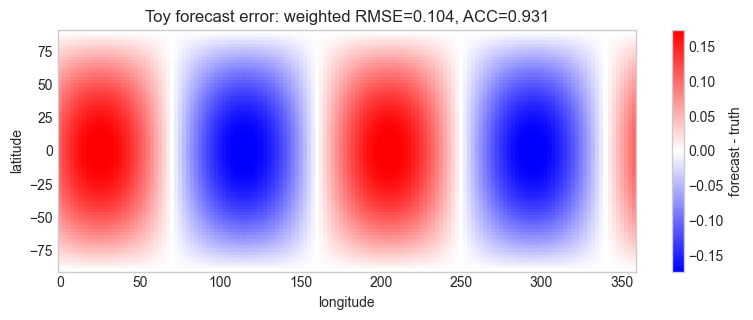

In [4]:
def latitude_weighted_rmse(pred, truth, lat_deg):
    weights = np.cos(np.deg2rad(lat_deg))[:, None]
    return np.sqrt(np.sum(weights * (pred - truth) ** 2) / np.sum(weights * np.ones_like(truth)))


def anomaly_correlation(pred, truth, climatology, lat_deg):
    weights = np.cos(np.deg2rad(lat_deg))[:, None]
    pred_anom = pred - climatology
    truth_anom = truth - climatology
    numerator = np.sum(weights * pred_anom * truth_anom)
    denominator = np.sqrt(np.sum(weights * pred_anom**2) * np.sum(weights * truth_anom**2))
    return numerator / denominator


lat = np.linspace(-90, 90, 73)
lon = np.linspace(0, 360, 144, endpoint=False)
Lon, Lat = np.meshgrid(lon, lat)

truth_map = np.sin(np.deg2rad(Lat)) + 0.35 * np.cos(3 * np.deg2rad(Lon)) * np.cos(np.deg2rad(Lat))
forecast_map = truth_map + 0.18 * np.sin(2 * np.deg2rad(Lon + 20)) * np.cos(np.deg2rad(Lat))
climatology = 0.7 * np.sin(np.deg2rad(Lat))

rmse = latitude_weighted_rmse(forecast_map, truth_map, lat)
acc = anomaly_correlation(forecast_map, truth_map, climatology, lat)
error = forecast_map - truth_map
vmax = np.percentile(np.abs(error), 98)

fig, ax = plt.subplots(figsize=(8, 3.3))
im = ax.pcolormesh(lon, lat, error, shading='auto', cmap='bwr', vmin=-vmax, vmax=vmax)
ax.set_title(f'Toy forecast error: weighted RMSE={rmse:.3f}, ACC={acc:.3f}')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
fig.colorbar(im, ax=ax, label='forecast - truth')
plt.tight_layout()
plt.show()

## 7. What pretrained inference requires

A pretrained global forecast model is not just a checkpoint. Reproducible inference requires a complete contract:

| Requirement | Why it matters |
|---|---|
| model code and weights | the checkpoint only works with the matching architecture |
| normalization constants | variables and levels must be transformed exactly as during training |
| variable list and ordering | missing or reordered channels invalidate the input |
| grid and vertical coordinates | the model expects a specific spatial/vertical representation |
| initial conditions | the input state must come from analysis/reanalysis or another accepted source |
| known forcings | time, solar/seasonal information, static fields, and boundary variables may be required |
| rollout logic | each predicted step must be fed back with the correct preprocessing/postprocessing |
| hardware and software | some models assume GPUs, mixed precision, FlashAttention, or model-specific packages |
| licenses and access | data, weights, and operational products can have different terms |

The AIFS v1.1 Hugging Face model card states that forecasts can be generated using `anemoi-inference`, retrieving initial conditions from ECMWF Open Data, downloading the checkpoint, creating a runner, and running the forecast. It also notes that the checkpoint contains model weights and that the model uses FlashAttention-related software/hardware assumptions.

For this classroom notebook, we use a FourCastNet-family workflow through NVIDIA Earth2Studio as the required live pretrained forecast example. Earth2Studio's deterministic example uses a built-in prognostic model, GFS data, and a Zarr output backend. That is not AIFS, but it is a concrete pretrained neural forecast workflow with the same basic inference contract.

In [5]:
pretrained_inference_contract = [
    'Install model-specific software',
    'Download or access model weights',
    'Retrieve initial conditions on the expected grid',
    'Apply the model normalization and variable ordering',
    'Run the six-hour forecast step',
    'Feed predictions back for autoregressive rollout',
    'Postprocess fields for plotting and verification',
]

print('Pretrained global forecast inference contract')
print('-' * 52)
for i, item in enumerate(pretrained_inference_contract, start=1):
    print(f'{i}. {item}')

Pretrained global forecast inference contract
----------------------------------------------------
1. Install model-specific software
2. Download or access model weights
3. Retrieve initial conditions on the expected grid
4. Apply the model normalization and variable ordering
5. Run the six-hour forecast step
6. Feed predictions back for autoregressive rollout
7. Postprocess fields for plotting and verification



## 8. Run a pretrained global forecast

This section runs a short pretrained neural weather forecast using Earth2Studio. We use this as the practical counterpart to the AIFS discussion: the exact architecture is not AIFS, but the workflow has the same operational shape.

```text
initial global state -> pretrained forecast operator -> autoregressive rollout -> forecast fields
```

The example uses Earth2Studio's built-in deterministic workflow:

- a pretrained DLWP model package,
- GFS initial-condition data,
- an in-memory Zarr output backend,
- four forecast steps, which gives a short forecast sequence.

The cell creates a fresh `GFS` datasource every time it runs. This matters because failed async data fetches can leave stale S3 sessions in a notebook kernel.


In [6]:

from dotenv import load_dotenv
from earth2studio.data import GFS
from earth2studio.io import ZarrBackend
from earth2studio.models.px import DLWP
import earth2studio.run as run

# AWS supports historical dates but uses s3fs/aiobotocore. DLWP requests
# multiple GFS lead-time inputs through one datasource. In some package
# combinations Earth2Studio closes the async S3 HTTP session after the first
# fetch, then reuses the same filesystem for the next fetch. Keep the session
# open for this short notebook run. Restarting the kernel cleans it up.
from aiobotocore.httpsession import AIOHTTPSession

if not hasattr(AIOHTTPSession, "_course_original_close"):
    AIOHTTPSession._course_original_close = AIOHTTPSession.close

async def _course_keep_open_close(self):
    return None

AIOHTTPSession.close = _course_keep_open_close

load_dotenv()

GFS_SOURCE = "aws"
FORECAST_DATE = "2025-01-01"
N_FORECAST_STEPS = 4

package = DLWP.load_default_package()
model = DLWP.load_model(package)

# Create fresh datasource and output objects for each run.
data = GFS(source=GFS_SOURCE, cache=True, verbose=True)
io = ZarrBackend()

io = run.deterministic(
    [FORECAST_DATE],
    N_FORECAST_STEPS,
    prognostic=model,
    data=data,
    io=io,
)
print(io.root.tree())


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
2026-04-19 11:44:24.229 | INFO     | earth2studio.run:deterministic:75 - Running simple workflow!
2026-04-19 11:44:24.245 | INFO     | earth2studio.run:deterministic:82 - Inference device: cpu


Fetching GFS data:   0%|          | 0/7 [00:00<?, ?it/s]

2026-04-19 11:44:24.303 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20241231/18/atmos/gfs.t18z.pgrb2.0p25.f000 255082993-807891


Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 14.71it/s]


2026-04-19 11:44:24.654 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20241231/18/atmos/gfs.t18z.pgrb2.0p25.f000 423698826-1179184
2026-04-19 11:44:24.678 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20241231/18/atmos/gfs.t18z.pgrb2.0p25.f000 298939700-849232
2026-04-19 11:44:24.699 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20241231/18/atmos/gfs.t18z.pgrb2.0p25.f000 401225944-987171
2026-04-19 11:44:24.720 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20241231/18/atmos/gfs.t18z.pgrb2.0p25.f000 411816724-869023
2026-04-19 11:44:24.739 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20241231/18/atmos/gfs.t18z.pgrb2.0p25.f000 333475788-839481
2026-04-19 11:44:24.759 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS

...

Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 47.30it/s]


2026-04-19 11:44:24.867 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250101/00/atmos/gfs.t00z.pgrb2.0p25.f000 209862550-719252
2026-04-19 11:44:24.889 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250101/00/atmos/gfs.t00z.pgrb2.0p25.f000 252965780-806613
2026-04-19 11:44:24.910 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250101/00/atmos/gfs.t00z.pgrb2.0p25.f000 420556056-1176318
2026-04-19 11:44:24.960 | SUCCESS  | earth2studio.run:deterministic:106 - Fetched data from GFS
2026-04-19 11:44:24.971 | INFO     | earth2studio.run:deterministic:136 - Inference starting!


Running inference: 100%|██████████| 5/5 [00:01<00:00,  2.89it/s]

2026-04-19 11:44:26.703 | SUCCESS  | earth2studio.run:deterministic:146 - Inference complete


/
├── lat (721,) float64
├── lead_time (5,) timedelta64
├── lon (1440,) float64
├── t2m (1, 5, 721, 1440) float32
├── t850 (1, 5, 721, 1440) float32
├── tcwv (1, 5, 721, 1440) float32
├── time (1,) datetime64
├── z1000 (1, 5, 721, 1440) float32
├── z300 (1, 5, 721, 1440) float32
├── z500 (1, 5, 721, 1440) float32
└── z700 (1, 5, 721, 1440) float32

In [14]:
io['t2m'][0, -1].shape

(721, 1440)

available forecast variables: ['t2m', 'z300', 't850', 'z1000', 'z700', 'tcwv', 'z500']


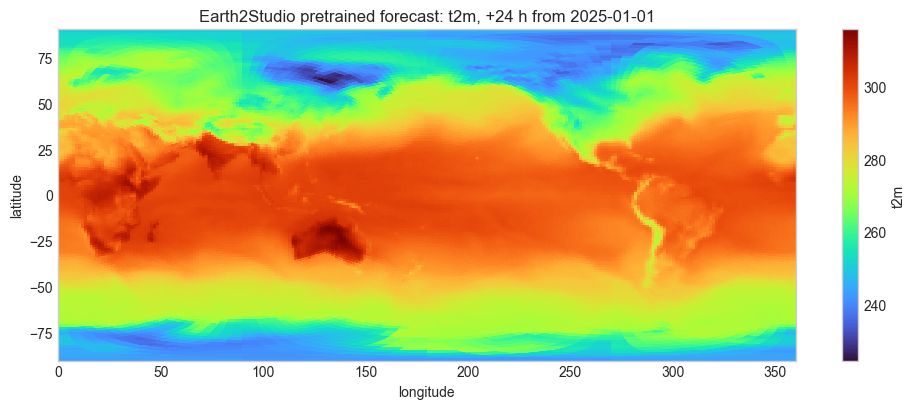

In [7]:

# Plot one forecast field from the pretrained rollout. DLWP's default package
# commonly outputs variables such as t2m, t850, z500, and tcwv.
available = [key for key in io.root.keys() if key not in {'lat', 'lon', 'time', 'lead_time'}]
print('available forecast variables:', available)

variable = 't2m' if 't2m' in available else available[0]
step = min(4, io[variable].shape[1] - 1)
field = io[variable][0, step]
lead_hours = int(io['lead_time'][step] / np.timedelta64(1, 'h'))

fig, ax = plt.subplots(figsize=(10, 4.2))
im = ax.pcolormesh(io['lon'][:], io['lat'][:], field, shading='auto', cmap='turbo')
ax.set_title(f'Earth2Studio pretrained forecast: {variable}, +{lead_hours} h from {FORECAST_DATE}')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
fig.colorbar(im, ax=ax, label=variable)
plt.tight_layout()
plt.show()



## 9. Takeaways

- AIFS is a learned weather forecast operator: $X_t \mapsto X_{t+6\mathrm{h}}$, rolled out autoregressively.
- Its architecture can be understood as encoder, latent processor, and decoder, using graph neural networks and transformer-style processing rather than a purely spectral FNO layer.
- The data object is a global, multi-variable, multi-level atmospheric state with known time-dependent and static forcings.
- One-step skill is not enough; rollout stability, variable scaling, lead-time behavior, and operational verification are central.
- Deterministic forecasts and probabilistic ensembles answer different questions.
- Pretrained inference requires the full model/data contract, and the Earth2Studio forecast demonstrates that contract in a runnable global forecast workflow.
